# ================================================================
# ROLE CATEGORISATION EXPERIMENT (NON-RAG) — CHAIN-OF-THOUGHT PROMPTING
# ================================================================

## Objective
This experiment evaluates the ability of a Large Language Model (LLM) to classify job descriptions into predefined role categories using chain-of-thought prompting (without RAG).

## Dataset
- Source: Djinni Job Descriptions Dataset
- Sample size: 100 job descriptions
- Columns used:
  - Long Description (input to LLM)
  - Position (original job title)
  - Primary Keyword
  - id (unique identifier)
  - standard_role (ground truth label)

## Role Taxonomy
A fixed taxonomy is used for classification.
This taxonomy is stored in:
- role_taxonomy.csv

Each job description must be classified into exactly one of the predefined roles:
Backend Developer, Frontend Developer, Full Stack Developer, DevOps Engineer,
Data / AI Role, QA Engineer, Mobile Developer, Software Engineer,
Project / Program Manager, Product Manager, Marketing / Sales,
Business / Operations Role, Design / Creative Role, Other

## Experimental Setup
- Approach: Chain-Of-Thought Prompting (Non-RAG)
- Model: llama-3.1-8b-instant (Groq)
- Temperature: 0.0
- Max Tokens: 700
- Input: Job Description
- Output: One role label from taxonomy

## Methodology
1. Load dataset with standardized roles
2. Clean and preprocess job descriptions
3. Build chain-of-thought prompt with role taxonomy
4. Send prompt to LLM
5. Capture predicted label
6. Compare prediction with ground truth (standard_role)
7. Store results for all samples

## Evaluation Metrics
- Accuracy
- Precision (Macro)
- Recall (Macro)
- F1-score (Macro)
- Confusion Matrix

## Outputs
- results.csv
- results.json
- final_metrics.csv
- final_metrics.json

## Purpose
This serves as a baseline experiment for role categorisation without retrieval.
Results will later be compared with RAG-based approaches.
# ================================================================

In [1]:
# ================================================================
# INSTALL REQUIRED LIBRARIES
# ================================================================
!pip install -q pandas numpy scikit-learn groq tenacity tqdm matplotlib seaborn

print("=" * 60)
print("Required Libraries installed")
print("=" * 60)

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 142.3/142.3 kB 13.9 MB/s eta 0:00:00
Required Libraries installed


LIBRARY VERSION CHECK
pandas       : 2.2.2
numpy        : 2.0.2
scikit-learn : 1.6.1
groq         : 1.2.0
tenacity     : 9.1.4
Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Project directory: /content/drive/MyDrive/Colab Notebooks/Masters/LJMU-masters-thesis
GROQ API key loaded from Colab secrets
EXPERIMENT CONFIGURATION
Experiment ID       : exp_37_rc_cot_nonrag_llama_3_1_8b_instant
Task                : role_categorization
Prompt type         : chain_of_thought_without_rag
Model               : llama-3.1-8b-instant
Temperature         : 0.0
Max tokens          : 700
Input               : Job Description only
RAG                 : No
Run sample size     : None
Dataset path        : /content/drive/MyDrive/Colab Notebooks/Masters/LJMU-masters-thesis/data/role_labels/djinni_with_standardized_roles.csv
Taxonomy path       : /content/drive/MyDrive/Colab Notebooks/Masters/LJMU-masters-thesis/data/role_labels/

,Position,Long Description,Company Name,Exp Years,Primary Keyword,English Level,Published,Long Description_lang,id,index_level_0,Reference_Summary,position_normalized,standard_role
0,Java Developer,The job holder will . Design develop and maint...,Quickstarter,3y,Java,upper,2021-12-01T00:00:00+02:00,en,67aefec1-1efc-5c5b-b2db-c0ef5b74f519,77261,Role Overview:\nThe Java Developer will design...,java developer,Backend Developer
1,Integration specialist / DevOps,Project Description Join our Development Cente...,Luxoft,3y,DevOps,upper,2022-04-01T00:00:00+03:00,en,2ec599d6-1509-5c34-9aec-54ac2e04b2d5,72279,Role Overview:\nThe Integration Specialist / D...,integration specialist devops,DevOps Engineer
2,Head of Marketing,TurnKey Labs is the most trusted offshore soft...,TurnKey Labs,5y,Marketing,upper,2021-10-01T00:00:00+03:00,en,edba8bfd-8a91-5b37-9f72-bde92397e804,69706,"Role Overview:\nReporting to the CEO, the Head...",head of marketing,Marketing / Sales


Role taxonomy preview


,role_id,standard_role,description,example_keywords
0,ROLE_01,Backend Developer,Server-side development roles involving backen...,"backend, java, spring, python developer, node...."
1,ROLE_02,Frontend Developer,Client-side development roles involving web UI...,"frontend, front-end, react, angular, vue, java..."
2,ROLE_03,Full Stack Developer,Roles requiring both frontend and backend deve...,"full stack, full-stack, fullstack, mern, mean"
3,ROLE_04,DevOps Engineer,"Infrastructure, CI/CD, cloud, deployment, auto...","devops, cloud, aws, azure, gcp, kubernetes, do..."
4,ROLE_05,Data / AI Role,"Data science, data engineering, machine learni...","data scientist, data engineer, machine learnin..."
5,ROLE_06,QA Engineer,"Software testing, quality assurance, automatio...","qa, quality assurance, tester, test engineer, ..."
6,ROLE_07,Mobile Developer,Mobile application development roles involving...,"android, ios, mobile, flutter, react native, k..."
7,ROLE_08,Project / Program Manager,"Project management, delivery management, scrum...","project manager, program manager, delivery man..."
8,ROLE_09,Product Manager,"Product ownership, product strategy, product m...","product manager, product owner, product lead"
9,ROLE_10,Marketing / Sales,"Marketing, sales, business development, custom...","marketing, sales, business development, growth..."


REQUIRED COLUMN VALIDATION
FOUND: id
FOUND: Long Description
FOUND: Position
FOUND: Primary Keyword
FOUND: standard_role
DATA CLEANING SUMMARY
Original rows          : 100
Rows after cleaning    : 100
Rows removed           : 0
Duplicate removal      : Applied on Long Description
Minimum JD word count  : 30


...

,experiment_id,task_name,prompt_type,model_name,temperature,max_tokens,rag_used,input_type,num_samples_completed,num_correct,num_incorrect,valid_label_rate,accuracy,precision_macro,recall_macro,f1_macro,precision_weighted,recall_weighted,f1_weighted,num_taxonomy_labels
0,exp_37_rc_cot_nonrag_llama_3_1_8b_instant,role_categorization,chain_of_thought_without_rag,llama-3.1-8b-instant,0.0,700,False,job_description_only,100,60,40,1.0,0.6,0.5912,0.6958,0.5965,0.5831,0.6,0.5704,13


CLASSIFICATION REPORT SAVED
Saved file: /content/drive/MyDrive/Colab Notebooks/Masters/LJMU-masters-thesis/outputs/experiments/role_categorization/without_rag/exp_37/classification_report.csv


,label,precision,recall,f1-score,support
0,Backend Developer,0.590909,0.684211,0.634146,19.0
1,Frontend Developer,1.000000,0.625000,0.769231,8.0
2,Full Stack Developer,0.500000,0.500000,0.500000,6.0
3,DevOps Engineer,0.700000,0.875000,0.777778,8.0
4,Data / AI Role,0.750000,1.000000,0.857143,3.0
5,QA Engineer,0.700000,1.000000,0.823529,7.0
6,Mobile Developer,1.000000,0.750000,0.857143,4.0
7,Project / Program Manager,0.250000,1.000000,0.400000,3.0
8,Product Manager,0.250000,1.000000,0.400000,1.0
9,Marketing / Sales,0.833333,0.500000,0.625000,10.0


CONFUSION MATRIX


,Backend Developer,Frontend Developer,Full Stack Developer,DevOps Engineer,Data / AI Role,QA Engineer,Mobile Developer,Project / Program Manager,Product Manager,Marketing / Sales,Business / Operations Role,Design / Creative Role,Other
Backend Developer,13,0,2,0,0,1,0,3,0,0,0,0,0
Frontend Developer,2,5,1,0,0,0,0,0,0,0,0,0,0
Full Stack Developer,1,0,3,0,0,0,0,1,0,0,1,0,0
DevOps Engineer,1,0,0,7,0,0,0,0,0,0,0,0,0
Data / AI Role,0,0,0,0,3,0,0,0,0,0,0,0,0
QA Engineer,0,0,0,0,0,7,0,0,0,0,0,0,0
Mobile Developer,0,0,0,0,0,0,3,0,1,0,0,0,0
Project / Program Manager,0,0,0,0,0,0,0,3,0,0,0,0,0
Product Manager,0,0,0,0,0,0,0,0,1,0,0,0,0
Marketing / Sales,2,0,0,0,0,0,0,0,0,5,2,1,0


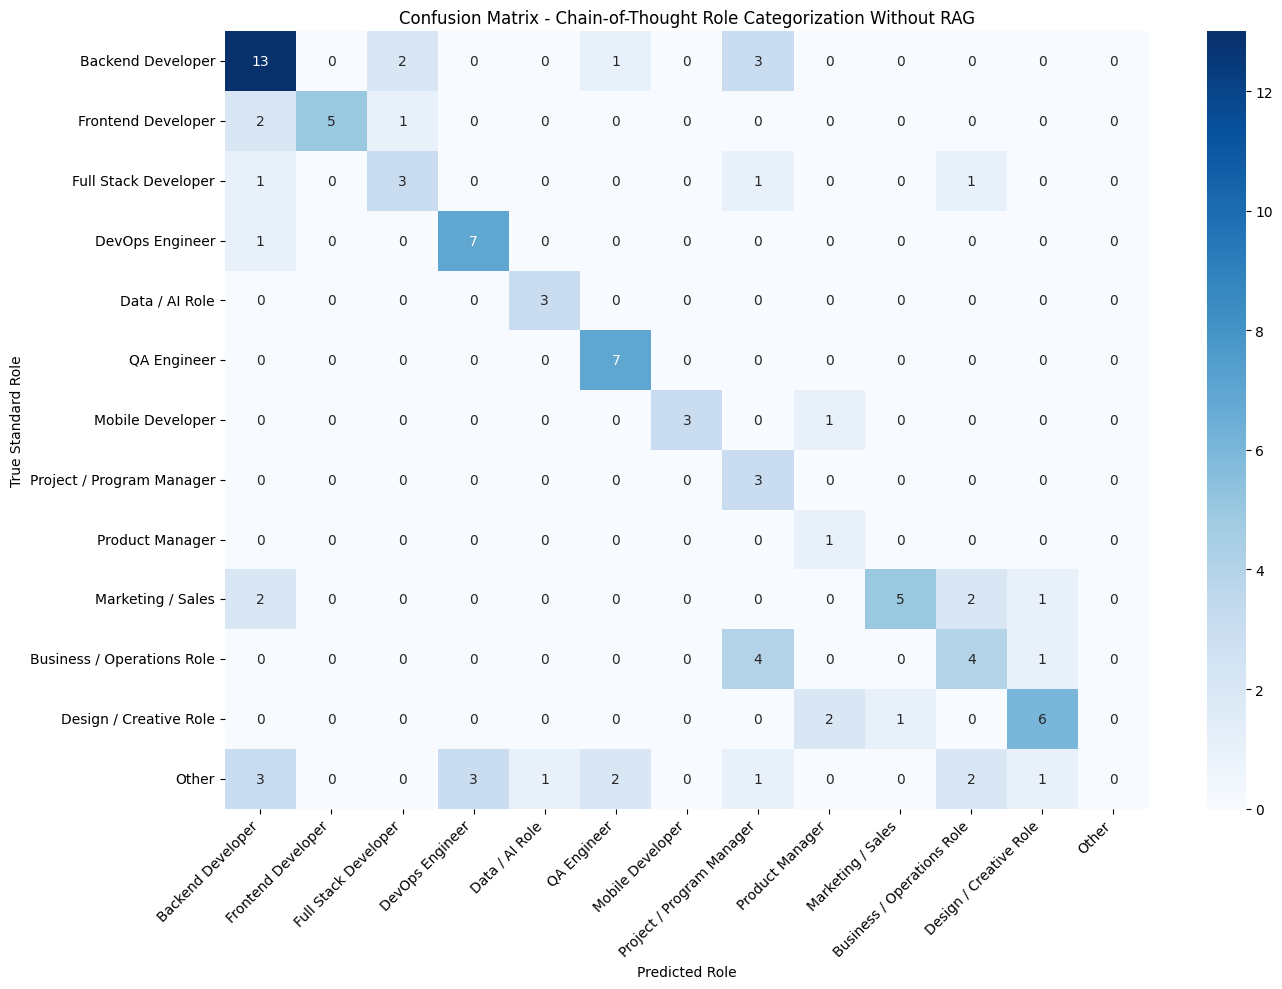

Saved confusion matrix CSV: /content/drive/MyDrive/Colab Notebooks/Masters/LJMU-masters-thesis/outputs/experiments/role_categorization/without_rag/exp_37/confusion_matrix.csv
Saved confusion matrix PNG: /content/drive/MyDrive/Colab Notebooks/Masters/LJMU-masters-thesis/outputs/experiments/role_categorization/without_rag/exp_37/confusion_matrix.png
ERROR ANALYSIS
Total incorrect predictions: 40


,selected_id,position,primary_keyword,standard_role,predicted_role,raw_prediction
7,b5fc4457-65a2-51c9-92fe-b9be2fc4888c,Golang Engineer,Golang,Backend Developer,Project / Program Manager,Project / Program Manager
13,345fde08-2c9b-51b6-aaef-e0d10cbe15b0,Junior Salesforce Developer,JavaScript,Marketing / Sales,Backend Developer,Backend Developer
15,1033d838-1753-5d48-8a93-3981e34666f6,Analyst Relations Manager,Business Analyst,Other,Business / Operations Role,Business / Operations Role
17,03d5d9fe-f19b-5baa-9f80-29d3bf3cd9c7,WFM Real Time Analyst,Other,Other,Business / Operations Role,Business / Operations Role
19,4ebda3a8-6249-5bc8-8118-6e21be66a1de,English writer,Technical Writing,Design / Creative Role,Marketing / Sales,Marketing / Sales
20,9b343996-ce39-56ad-bed1-ccb5a41814fc,Product Manager iOS,Product Manager,Mobile Developer,Product Manager,Product Manager
21,66a7dbc2-c188-5afa-a2fa-f729ef2292b2,Performance Engineer (Python),Python,Other,DevOps Engineer,DevOps Engineer
24,cc8a84c0-8df5-5e44-9793-50991b3e46e2,Front-end Developer React,JavaScript,Frontend Developer,Backend Developer,Backend Developer
26,8c51792f-fb89-5d0a-9515-283bf72e3246,Senior Fullstack Developer,JavaScript,Full Stack Developer,Backend Developer,Backend Developer
29,89e75f7e-a2cb-5cb5-a3ed-01b61882b538,Full stack - team leader,JavaScript,Full Stack Developer,Project / Program Manager,Project / Program Manager


FINAL OUTPUT FILES
1. Results CSV             : /content/drive/MyDrive/Colab Notebooks/Masters/LJMU-masters-thesis/outputs/experiments/role_categorization/without_rag/exp_37/results.csv
2. Results JSON            : /content/drive/MyDrive/Colab Notebooks/Masters/LJMU-masters-thesis/outputs/experiments/role_categorization/without_rag/exp_37/results.json
3. Final metrics CSV       : /content/drive/MyDrive/Colab Notebooks/Masters/LJMU-masters-thesis/outputs/experiments/role_categorization/without_rag/exp_37/final_metrics.csv
4. Final metrics JSON      : /content/drive/MyDrive/Colab Notebooks/Masters/LJMU-masters-thesis/outputs/experiments/role_categorization/without_rag/exp_37/final_metrics.json
5. Confusion matrix CSV    : /content/drive/MyDrive/Colab Notebooks/Masters/LJMU-masters-thesis/outputs/experiments/role_categorization/without_rag/exp_37/confusion_matrix.csv
6. Confusion matrix PNG    : /content/drive/MyDrive/Colab Notebooks/Masters/LJMU-masters-thesis/outputs/experiments/role_ca

In [3]:
# ================================================================
# 1. BASIC PYTHON LIBRARIES
# ================================================================
import os
import re
import json
import time
import random
import warnings
import importlib.metadata
from pathlib import Path

import numpy as np
import pandas as pd

from tqdm.auto import tqdm

warnings.filterwarnings("ignore")

# ================================================================
# 2. ML / EVALUATION LIBRARIES
# ================================================================
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    classification_report
)

import matplotlib.pyplot as plt
import seaborn as sns

# ================================================================
# 3. LLM LIBRARIES
# ================================================================
from groq import Groq, RateLimitError
from tenacity import retry, stop_after_attempt, wait_exponential, retry_if_exception_type

# ================================================================
# 4. GOOGLE COLAB / DRIVE
# ================================================================
from google.colab import drive, userdata

# ================================================================
# 5. VERSION CHECKS
# ================================================================
def get_version(pkg):
    try:
        return importlib.metadata.version(pkg)
    except Exception:
        return "installed"


print("=" * 60)
print("LIBRARY VERSION CHECK")
print("=" * 60)
print("pandas       :", pd.__version__)
print("numpy        :", np.__version__)
print("scikit-learn :", get_version("scikit-learn"))
print("groq         :", get_version("groq"))
print("tenacity     :", get_version("tenacity"))
print("=" * 60)

# ================================================================
# 6. MOUNT GOOGLE DRIVE
# ================================================================
drive.mount("/content/drive")

PROJECT_DIR = Path("/content/drive/MyDrive/Colab Notebooks/Masters/LJMU-masters-thesis")
PROJECT_DIR.mkdir(parents=True, exist_ok=True)

print("Project directory:", PROJECT_DIR)

# ================================================================
# 7. LOAD GROQ API KEY
# ================================================================
GROQ_API_KEY = userdata.get("GROQ_API_KEY_1")
assert GROQ_API_KEY, "GROQ_API_KEY is missing in Colab Secrets."

os.environ["GROQ_API_KEY"] = GROQ_API_KEY

print("GROQ API key loaded from Colab secrets")

# ================================================================
# 8. EXPERIMENT CONFIGURATION
# ================================================================

# -----------------------------
# Dataset paths
# -----------------------------
ROLE_LABEL_DATA_DIR = PROJECT_DIR / "data" / "role_labels"

STANDARDIZED_DATASET_PATH = ROLE_LABEL_DATA_DIR / "djinni_with_standardized_roles.csv"
ROLE_TAXONOMY_PATH = ROLE_LABEL_DATA_DIR / "role_taxonomy.csv"

# -----------------------------
# Required columns
# -----------------------------
TEXT_COLUMN = "Long Description"
ID_COLUMN = "id"
POSITION_COLUMN = "Position"
PRIMARY_KEYWORD_COLUMN = "Primary Keyword"
STANDARD_ROLE_COLUMN = "standard_role"

# -----------------------------
# Experiment metadata
# -----------------------------
EXPERIMENT_ID = "exp_37_rc_cot_nonrag_llama_3_1_8b_instant"
TASK_NAME = "role_categorization"
PROMPT_TYPE = "chain_of_thought_without_rag"
MODEL_NAME = "llama-3.1-8b-instant"
OUTPUT_FOLDER_NAME = "exp_37"

TEMPERATURE = 0.0
MAX_TOKENS = 700

# For testing, set RUN_SAMPLE_SIZE = 10
# For final run, set RUN_SAMPLE_SIZE = None
RUN_SAMPLE_SIZE = None

# -----------------------------
# Output paths
# -----------------------------
OUTPUT_DIR = PROJECT_DIR / "outputs" / "experiments" / "role_categorization"/ "without_rag" / OUTPUT_FOLDER_NAME
OUTPUT_DIR.mkdir(parents=True, exist_ok=True)

RESULTS_CSV = OUTPUT_DIR / "results.csv"
RESULTS_JSON = OUTPUT_DIR / "results.json"

FAILED_RESULTS_CSV = OUTPUT_DIR / "failed_results.csv"

FINAL_METRICS_CSV = OUTPUT_DIR / "final_metrics.csv"
FINAL_METRICS_JSON = OUTPUT_DIR / "final_metrics.json"

CONFUSION_MATRIX_CSV = OUTPUT_DIR / "confusion_matrix.csv"
CONFUSION_MATRIX_PNG = OUTPUT_DIR / "confusion_matrix.png"

CLASSIFICATION_REPORT_CSV = OUTPUT_DIR / "classification_report.csv"

print("=" * 60)
print("EXPERIMENT CONFIGURATION")
print("=" * 60)
print("Experiment ID       :", EXPERIMENT_ID)
print("Task                :", TASK_NAME)
print("Prompt type         :", PROMPT_TYPE)
print("Model               :", MODEL_NAME)
print("Temperature         :", TEMPERATURE)
print("Max tokens          :", MAX_TOKENS)
print("Input               : Job Description only")
print("RAG                 : No")
print("Run sample size     :", RUN_SAMPLE_SIZE)
print("Dataset path        :", STANDARDIZED_DATASET_PATH)
print("Taxonomy path       :", ROLE_TAXONOMY_PATH)
print("Output dir          :", OUTPUT_DIR)
print("=" * 60)

# ================================================================
# 9. LOAD STANDARDIZED DATASET AND ROLE TAXONOMY
# ================================================================
print("=" * 60)
print("Loading standardized Djinni dataset and role taxonomy...")
print("=" * 60)

if not STANDARDIZED_DATASET_PATH.exists():
    raise FileNotFoundError(f"Standardized dataset not found: {STANDARDIZED_DATASET_PATH}")

if not ROLE_TAXONOMY_PATH.exists():
    raise FileNotFoundError(f"Role taxonomy file not found: {ROLE_TAXONOMY_PATH}")

df = pd.read_csv(STANDARDIZED_DATASET_PATH)
taxonomy_df = pd.read_csv(ROLE_TAXONOMY_PATH)

print("Dataset loaded successfully")
print("Dataset shape :", df.shape)
print("Dataset columns:", list(df.columns))

print("\nRole taxonomy loaded successfully")
print("Taxonomy shape :", taxonomy_df.shape)
print("Taxonomy columns:", list(taxonomy_df.columns))

print("=" * 60)
print("Dataset preview")
print("=" * 60)
display(df.head(3))

print("=" * 60)
print("Role taxonomy preview")
print("=" * 60)
display(taxonomy_df)


# ================================================================
# 10. VALIDATE REQUIRED COLUMNS
# ================================================================
required_columns = [
    ID_COLUMN,
    TEXT_COLUMN,
    POSITION_COLUMN,
    PRIMARY_KEYWORD_COLUMN,
    STANDARD_ROLE_COLUMN
]

missing_columns = [col for col in required_columns if col not in df.columns]

if missing_columns:
    raise ValueError(f"Missing required columns: {missing_columns}")

print("=" * 60)
print("REQUIRED COLUMN VALIDATION")
print("=" * 60)

for col in required_columns:
    print(f"FOUND: {col}")

print("=" * 60)

# ================================================================
# 11. DATA CLEANING / PREPROCESSING
# ================================================================
def clean_text(text: str) -> str:
    """
    Cleans job description text.
    Removes HTML tags, URLs, excessive whitespace, and noisy characters.
    """
    if pd.isna(text):
        return ""

    text = str(text)

    # Remove HTML tags
    text = re.sub(r"<[^>]+>", " ", text)

    # Remove URLs
    text = re.sub(r"http\S+|www\S+", " ", text)

    # Normalize whitespace
    text = re.sub(r"\s+", " ", text).strip()

    return text


def preprocess_dataset(df: pd.DataFrame) -> pd.DataFrame:
    """
    Selects required fields, removes null records, cleans text,
    removes duplicate job descriptions, and removes noisy short records.
    """
    work_df = df[
        [
            ID_COLUMN,
            TEXT_COLUMN,
            POSITION_COLUMN,
            PRIMARY_KEYWORD_COLUMN,
            STANDARD_ROLE_COLUMN
        ]
    ].copy()

    original_count = len(work_df)

    # Remove null values in critical columns
    work_df = work_df.dropna(
        subset=[
            ID_COLUMN,
            TEXT_COLUMN,
            POSITION_COLUMN,
            STANDARD_ROLE_COLUMN
        ]
    )

    # Clean JD text
    work_df[TEXT_COLUMN] = work_df[TEXT_COLUMN].apply(clean_text)

    # Remove empty JDs
    work_df = work_df[work_df[TEXT_COLUMN].str.strip().ne("")]

    # Remove very short/noisy JDs
    work_df["jd_word_count"] = work_df[TEXT_COLUMN].apply(lambda x: len(str(x).split()))
    work_df = work_df[work_df["jd_word_count"] >= 30]

    # Remove duplicate JDs
    work_df = work_df.drop_duplicates(subset=[TEXT_COLUMN]).reset_index(drop=True)

    cleaned_count = len(work_df)

    print("=" * 60)
    print("DATA CLEANING SUMMARY")
    print("=" * 60)
    print("Original rows          :", original_count)
    print("Rows after cleaning    :", cleaned_count)
    print("Rows removed           :", original_count - cleaned_count)
    print("Duplicate removal      : Applied on Long Description")
    print("Minimum JD word count  : 30")
    print("=" * 60)

    return work_df


clean_df = preprocess_dataset(df)

display(clean_df.head(3))

# ================================================================
# 12. VALIDATE ROLE LABELS AGAINST TAXONOMY
# ================================================================
ROLE_LABELS = taxonomy_df["standard_role"].dropna().astype(str).tolist()

dataset_roles = sorted(clean_df[STANDARD_ROLE_COLUMN].dropna().unique().tolist())
taxonomy_roles = sorted(ROLE_LABELS)

unknown_roles = sorted(set(dataset_roles) - set(taxonomy_roles))

if unknown_roles:
    raise ValueError(f"Dataset contains roles not present in taxonomy: {unknown_roles}")

print("=" * 60)
print("ROLE LABEL VALIDATION")
print("=" * 60)
print("Number of taxonomy labels :", len(ROLE_LABELS))
print("Dataset role labels       :", len(dataset_roles))
print("\nRole labels:")
for role in ROLE_LABELS:
    print("-", role)
print("=" * 60)

role_distribution = (
    clean_df[STANDARD_ROLE_COLUMN]
    .value_counts()
    .reset_index()
)

role_distribution.columns = ["standard_role", "count"]
role_distribution["percentage"] = round(role_distribution["count"] / len(clean_df) * 100, 2)

display(role_distribution)

# ================================================================
# 13. SELECT EXPERIMENT SUBSET
# ================================================================
if RUN_SAMPLE_SIZE is not None:
    experiment_df = clean_df.head(RUN_SAMPLE_SIZE).copy().reset_index(drop=True)
else:
    experiment_df = clean_df.copy().reset_index(drop=True)

print("=" * 60)
print("EXPERIMENT DATASET")
print("=" * 60)
print("Total cleaned rows     :", len(clean_df))
print("Experiment rows        :", len(experiment_df))
print("Run sample size        :", RUN_SAMPLE_SIZE)
print("=" * 60)

display(experiment_df[[ID_COLUMN, POSITION_COLUMN, PRIMARY_KEYWORD_COLUMN, STANDARD_ROLE_COLUMN]].head(10))

# ================================================================
# 14. SELECT ONE JD USING ID FOR SANITY TEST
# ================================================================
# This section verifies that one JD can be selected using its id.
# You may change SAMPLE_ID manually if needed.

SAMPLE_ID = str(experiment_df.loc[0, ID_COLUMN])

sample_row = experiment_df[experiment_df[ID_COLUMN].astype(str) == SAMPLE_ID]

if sample_row.empty:
    raise ValueError(f"No JD found for id: {SAMPLE_ID}")

sample_row = sample_row.iloc[0]

print("=" * 60)
print("SINGLE JD SANITY CHECK")
print("=" * 60)
print("Selected ID       :", sample_row[ID_COLUMN])
print("Position          :", sample_row[POSITION_COLUMN])
print("Primary Keyword   :", sample_row[PRIMARY_KEYWORD_COLUMN])
print("Standard Role     :", sample_row[STANDARD_ROLE_COLUMN])
print("JD preview        :", sample_row[TEXT_COLUMN][:500])
print("=" * 60)

# ================================================================
# 15. CHAIN-OF-THOUGHT ROLE CATEGORIZATION PROMPT
# ================================================================
def build_role_list(role_labels):
    """
    Converts taxonomy labels into a numbered list for the prompt.
    """
    return "\n".join([f"{i+1}. {role}" for i, role in enumerate(role_labels)])


def build_cot_role_prompt(job_description: str, role_labels: list) -> str:
    """
    Builds a Chain-of-Thought style prompt for role categorization.

    The model is asked to internally analyse:
    - skills
    - responsibilities
    - tools / technologies

    But it must return only the final role label.
    """

    role_list_text = "\n".join([f"{i+1}. {role}" for i, role in enumerate(role_labels)])

    prompt = f"""
You are an expert HR role classification assistant.

Your task is to classify the given job description into exactly ONE role category.

You MUST choose only one label from the predefined role taxonomy below.

PREDEFINED ROLE TAXONOMY:
{role_list_text}

INTERNAL ANALYSIS INSTRUCTIONS:
Before selecting the final role, internally analyse:
1. Key skills mentioned in the job description
2. Main responsibilities described in the job description
3. Tools, technologies, platforms, or methods mentioned
4. The most likely role category based on the evidence

STRICT OUTPUT RULES:
- Do not show your analysis
- Do not explain your reasoning
- Do not return multiple labels
- Do not create a new label
- Do not include numbering
- Return only the final role label exactly as written in the taxonomy

JOB DESCRIPTION:
{job_description}

FINAL ROLE LABEL:
""".strip()

    return prompt


sample_prompt = build_cot_role_prompt(
    job_description=sample_row[TEXT_COLUMN],
    role_labels=ROLE_LABELS
)

print("=" * 60)
print("SAMPLE CHAIN-OF-THOUGHT PROMPT")
print("=" * 60)
print(sample_prompt[:2500])
print("=" * 60)

# ================================================================
# 16. GROQ CLIENT
# ================================================================
class LLMClientError(Exception):
    pass


class GroqClient:
    """
    Wrapper around Groq API for role categorization.
    """

    def __init__(self, model_name: str):
        api_key = os.getenv("GROQ_API_KEY")

        if not api_key:
            raise ValueError("GROQ_API_KEY is missing from environment variables.")

        self.client = Groq(api_key=api_key)
        self.model_name = model_name

    @retry(
        stop=stop_after_attempt(3),
        wait=wait_exponential(multiplier=1, min=2, max=10),
        retry=retry_if_exception_type(Exception),
        reraise=True
    )
    def generate(
        self,
        prompt: str,
        temperature: float,
        max_tokens: int
    ) -> str:
        completion = self.client.chat.completions.create(
            model=self.model_name,
            messages=[
                {
                    "role": "system",
                    "content": (
                        "You are a precise HR role classification assistant. "
                        "Return only one label from the provided taxonomy."
                    )
                },
                {
                    "role": "user",
                    "content": prompt
                }
            ],
            temperature=temperature,
            max_tokens=max_tokens
        )

        if not completion.choices:
            raise LLMClientError("Groq returned no choices.")

        text = completion.choices[0].message.content

        if not text or not str(text).strip():
            raise LLMClientError("Groq returned an empty response.")

        return str(text).strip()


print("Initialising LLM via Groq...")
groq_client = GroqClient(model_name=MODEL_NAME)
print("LLM ready:", MODEL_NAME)
print("=" * 60)

# ================================================================
# 17. PREDICTED LABEL CLEANING AND VALIDATION
# ================================================================
def normalize_label_text(text: str) -> str:
    """
    Normalizes LLM output for matching against taxonomy.
    """
    if pd.isna(text):
        return ""

    text = str(text).strip()

    # Remove markdown/code formatting if accidentally returned
    text = text.replace("`", "").replace("*", "").strip()

    # Remove common prefixes
    text = re.sub(r"^final role label\s*:\s*", "", text, flags=re.IGNORECASE)
    text = re.sub(r"^role\s*:\s*", "", text, flags=re.IGNORECASE)
    text = re.sub(r"^label\s*:\s*", "", text, flags=re.IGNORECASE)

    # Keep only first line if model returns extra text
    text = text.split("\n")[0].strip()

    # Remove numbering like "1. Backend Developer"
    text = re.sub(r"^\d+[\.\)]\s*", "", text).strip()

    return text

def validate_predicted_label(raw_prediction: str, role_labels: list):

    cleaned = normalize_label_text(raw_prediction)

    if cleaned in role_labels:
        return cleaned, True

    lower_map = {role.lower(): role for role in role_labels}
    if cleaned.lower() in lower_map:
        return lower_map[cleaned.lower()], True

    # HARD fallback
    return "Other", False

print("Prediction cleaning and validation functions ready")
print("=" * 60)

# ================================================================
# 18. SINGLE JD TEST
# ================================================================
print("=" * 60)
print("RUNNING SINGLE JD TEST")
print("=" * 60)

test_prompt = build_cot_role_prompt(
    job_description=sample_row[TEXT_COLUMN],
    role_labels=ROLE_LABELS
)

raw_prediction = groq_client.generate(
    prompt=test_prompt,
    temperature=TEMPERATURE,
    max_tokens=MAX_TOKENS
)

predicted_role, is_valid_label = validate_predicted_label(
    raw_prediction=raw_prediction,
    role_labels=ROLE_LABELS
)

print("Selected ID       :", sample_row[ID_COLUMN])
print("Position          :", sample_row[POSITION_COLUMN])
print("True standard_role:", sample_row[STANDARD_ROLE_COLUMN])
print("Raw prediction    :", raw_prediction)
print("Predicted role    :", predicted_role)
print("Valid label       :", is_valid_label)
print("Correct prediction:", predicted_role == sample_row[STANDARD_ROLE_COLUMN])
print("=" * 60)

# ================================================================
# 19. CHECKPOINT / RESUME
# ================================================================
if RESULTS_JSON.exists():
    with open(RESULTS_JSON, "r", encoding="utf-8") as f:
        loaded_results = json.load(f)

    if isinstance(loaded_results, list):
        all_results = loaded_results
        completed_ids = {
            str(row["selected_id"])
            for row in all_results
            if "selected_id" in row
        }
    else:
        all_results = []
        completed_ids = set()
else:
    all_results = []
    completed_ids = set()


if FAILED_RESULTS_CSV.exists():
    try:
        failed_results = pd.read_csv(FAILED_RESULTS_CSV).to_dict(orient="records")
    except Exception:
        failed_results = []
else:
    failed_results = []


print("=" * 60)
print("CHECKPOINT STATUS")
print("=" * 60)
print("Already completed:", len(completed_ids))
print("Already failed   :", len(failed_results))
print("=" * 60)

# ================================================================
# 20. CHECKPOINT SAVE FUNCTION
# ================================================================
def save_checkpoints(all_results, failed_results):
    """
    Saves intermediate results after each JD.
    This prevents loss of progress if rate limit or runtime interruption occurs.
    """
    with open(RESULTS_JSON, "w", encoding="utf-8") as f:
        json.dump(all_results, f, indent=2, ensure_ascii=False)

    if all_results:
        pd.DataFrame(all_results).to_csv(
            RESULTS_CSV,
            index=False,
            encoding="utf-8"
        )

    if failed_results:
        pd.DataFrame(failed_results).to_csv(
            FAILED_RESULTS_CSV,
            index=False,
            encoding="utf-8"
        )


print("Checkpoint save function ready")
print("=" * 60)

# ================================================================
# 21. RUN CHAIN-OF-THOUGHT NON-RAG ROLE CATEGORIZATION EXPERIMENT
# ================================================================
print("=" * 60)
print("RUNNING CHAIN-OF-THOUGHT ROLE CATEGORIZATION WITHOUT RAG")
print("=" * 60)
print("Samples     :", len(experiment_df))
print("Model       :", MODEL_NAME)
print("Temperature :", TEMPERATURE)
print("Max tokens  :", MAX_TOKENS)
print("Input       : Job Description only")
print("=" * 60)


for i, row in tqdm(
    experiment_df.iterrows(),
    total=len(experiment_df),
    desc="Running Chain-Of-Thought Role Categorization",
    unit="JD"
):
    current_id = str(row[ID_COLUMN])

    if current_id in completed_ids:
        tqdm.write(f"Skipped {i+1}/{len(experiment_df)} | ID: {current_id}")
        continue

    tqdm.write("=" * 60)
    tqdm.write(f"Running {i+1}/{len(experiment_df)} | ID: {current_id}")

    try:
        job_description = row[TEXT_COLUMN]
        position = row[POSITION_COLUMN]
        primary_keyword = row[PRIMARY_KEYWORD_COLUMN]
        true_role = row[STANDARD_ROLE_COLUMN]

        # 1. Build chain-of-thought prompt
        prompt = build_cot_role_prompt(
            job_description=job_description,
            role_labels=ROLE_LABELS
        )

        # 2. Send prompt to LLM
        raw_prediction = groq_client.generate(
            prompt=prompt,
            temperature=TEMPERATURE,
            max_tokens=MAX_TOKENS
        )

        # 3. Clean and validate predicted label
        predicted_role, is_valid_label = validate_predicted_label(
            raw_prediction=raw_prediction,
            role_labels=ROLE_LABELS
        )

        # 4. Compare prediction with ground-truth standardized role
        is_correct = predicted_role == true_role

        result = {
            "experiment_id": EXPERIMENT_ID,
            "selected_id": current_id,
            "prompt_type": PROMPT_TYPE,
            "model_name": MODEL_NAME,
            "temperature": TEMPERATURE,
            "max_tokens": MAX_TOKENS,

            "position": position,
            "primary_keyword": primary_keyword,
            "job_description": job_description,

            "standard_role": true_role,
            "raw_prediction": raw_prediction,
            "predicted_role": predicted_role,
            "is_valid_label": is_valid_label,
            "is_correct": is_correct
        }

        all_results.append(result)
        completed_ids.add(current_id)

        save_checkpoints(all_results, failed_results)

        tqdm.write(
            f"Completed {i+1}/{len(experiment_df)} | "
            f"True: {true_role} | "
            f"Predicted: {predicted_role} | "
            f"Correct: {is_correct}"
        )

    except RateLimitError as e:
        tqdm.write("Rate limit hit. Checkpoint saved.")
        tqdm.write(str(e))
        save_checkpoints(all_results, failed_results)
        break

    except Exception as e:
        tqdm.write(
            f"Failed {i+1}/{len(experiment_df)} | "
            f"ID: {current_id} | Error: {e}"
        )

        failed_results.append({
            "selected_id": current_id,
            "error": str(e)
        })

        save_checkpoints(all_results, failed_results)
        continue


print("=" * 60)
print("EXPERIMENT COMPLETE")
print("Successful results:", len(all_results))
print("Failed results    :", len(failed_results))
print("Results CSV       :", RESULTS_CSV)
print("Results JSON      :", RESULTS_JSON)
print("=" * 60)

# ================================================================
# 22. FINAL METRICS STRATEGY
# ================================================================
"""
Final metrics strategy:

1. Use standard_role as the ground-truth label.
2. Use predicted_role as the model output.
3. Compute overall Accuracy.
4. Compute macro Precision, Recall, and F1-score.
   Macro averaging is preferred because the dataset is small and class distribution is imbalanced.
5. Also compute weighted Precision, Recall, and F1-score.
   Weighted averaging reflects class frequency.
6. Generate a confusion matrix to inspect which roles are confused.
7. Save all metrics in final_metrics.csv and final_metrics.json.
8. Save detailed per-class classification report in classification_report.csv.
9. Save confusion matrix as both CSV and PNG.
"""
print("Final metrics strategy documented.")

# ================================================================
# 23. COMPUTE FINAL CLASSIFICATION METRICS
# ================================================================
results_df = pd.DataFrame(all_results)

if results_df.empty:
    raise ValueError("No results available. Run the experiment first.")

# Keep only rows with valid required fields
results_df = results_df.dropna(subset=["standard_role", "predicted_role"]).copy()

y_true = results_df["standard_role"].astype(str)
y_pred = results_df["predicted_role"].astype(str)

labels_for_metrics = ROLE_LABELS

accuracy = accuracy_score(y_true, y_pred)

precision_macro = precision_score(
    y_true,
    y_pred,
    labels=labels_for_metrics,
    average="macro",
    zero_division=0
)

recall_macro = recall_score(
    y_true,
    y_pred,
    labels=labels_for_metrics,
    average="macro",
    zero_division=0
)

f1_macro = f1_score(
    y_true,
    y_pred,
    labels=labels_for_metrics,
    average="macro",
    zero_division=0
)

precision_weighted = precision_score(
    y_true,
    y_pred,
    labels=labels_for_metrics,
    average="weighted",
    zero_division=0
)

recall_weighted = recall_score(
    y_true,
    y_pred,
    labels=labels_for_metrics,
    average="weighted",
    zero_division=0
)

f1_weighted = f1_score(
    y_true,
    y_pred,
    labels=labels_for_metrics,
    average="weighted",
    zero_division=0
)

valid_label_rate = results_df["is_valid_label"].mean()
correct_count = int(results_df["is_correct"].sum())
incorrect_count = int(len(results_df) - correct_count)

final_metrics = {
    "experiment_id": EXPERIMENT_ID,
    "task_name": TASK_NAME,
    "prompt_type": PROMPT_TYPE,
    "model_name": MODEL_NAME,
    "temperature": TEMPERATURE,
    "max_tokens": MAX_TOKENS,
    "rag_used": False,
    "input_type": "job_description_only",

    "num_samples_completed": int(len(results_df)),
    "num_correct": correct_count,
    "num_incorrect": incorrect_count,
    "valid_label_rate": round(float(valid_label_rate), 4),

    "accuracy": round(float(accuracy), 4),

    "precision_macro": round(float(precision_macro), 4),
    "recall_macro": round(float(recall_macro), 4),
    "f1_macro": round(float(f1_macro), 4),

    "precision_weighted": round(float(precision_weighted), 4),
    "recall_weighted": round(float(recall_weighted), 4),
    "f1_weighted": round(float(f1_weighted), 4),

    "num_taxonomy_labels": len(labels_for_metrics)
}

final_metrics_df = pd.DataFrame([final_metrics])

final_metrics_df.to_csv(FINAL_METRICS_CSV, index=False, encoding="utf-8")

with open(FINAL_METRICS_JSON, "w", encoding="utf-8") as f:
    json.dump(final_metrics, f, indent=4, ensure_ascii=False)

print("=" * 60)
print("FINAL METRICS — CHAIN-OF-THOUGHT ROLE CATEGORIZATION WITHOUT RAG")
print("=" * 60)
print("Samples completed :", final_metrics["num_samples_completed"])
print("Correct           :", final_metrics["num_correct"])
print("Incorrect         :", final_metrics["num_incorrect"])
print("Valid label rate  :", final_metrics["valid_label_rate"])
print("Accuracy          :", final_metrics["accuracy"])
print("Precision Macro   :", final_metrics["precision_macro"])
print("Recall Macro      :", final_metrics["recall_macro"])
print("F1 Macro          :", final_metrics["f1_macro"])
print("Precision Weighted:", final_metrics["precision_weighted"])
print("Recall Weighted   :", final_metrics["recall_weighted"])
print("F1 Weighted       :", final_metrics["f1_weighted"])
print("=" * 60)

print("Saved final metrics CSV :", FINAL_METRICS_CSV)
print("Saved final metrics JSON:", FINAL_METRICS_JSON)

display(final_metrics_df)

# ================================================================
# 24. CLASSIFICATION REPORT
# ================================================================
report_dict = classification_report(
    y_true,
    y_pred,
    labels=labels_for_metrics,
    output_dict=True,
    zero_division=0
)

classification_report_df = pd.DataFrame(report_dict).transpose().reset_index()
classification_report_df = classification_report_df.rename(columns={"index": "label"})

classification_report_df.to_csv(
    CLASSIFICATION_REPORT_CSV,
    index=False,
    encoding="utf-8"
)

print("=" * 60)
print("CLASSIFICATION REPORT SAVED")
print("=" * 60)
print("Saved file:", CLASSIFICATION_REPORT_CSV)
print("=" * 60)

display(classification_report_df)

# ================================================================
# 25. CONFUSION MATRIX
# ================================================================
cm = confusion_matrix(
    y_true,
    y_pred,
    labels=labels_for_metrics
)

cm_df = pd.DataFrame(
    cm,
    index=labels_for_metrics,
    columns=labels_for_metrics
)

cm_df.to_csv(CONFUSION_MATRIX_CSV, encoding="utf-8")

print("=" * 60)
print("CONFUSION MATRIX")
print("=" * 60)
display(cm_df)

plt.figure(figsize=(14, 10))
sns.heatmap(
    cm_df,
    annot=True,
    fmt="d",
    cmap="Blues"
)

plt.title("Confusion Matrix - Chain-of-Thought Role Categorization Without RAG")
plt.xlabel("Predicted Role")
plt.ylabel("True Standard Role")
plt.xticks(rotation=45, ha="right")
plt.yticks(rotation=0)
plt.tight_layout()

plt.savefig(CONFUSION_MATRIX_PNG, dpi=300, bbox_inches="tight")
plt.show()

print("Saved confusion matrix CSV:", CONFUSION_MATRIX_CSV)
print("Saved confusion matrix PNG:", CONFUSION_MATRIX_PNG)

# ================================================================
# 26. ERROR ANALYSIS
# ================================================================
incorrect_df = results_df[results_df["is_correct"] == False].copy()

print("=" * 60)
print("ERROR ANALYSIS")
print("=" * 60)
print("Total incorrect predictions:", len(incorrect_df))
print("=" * 60)

display(
    incorrect_df[
        [
            "selected_id",
            "position",
            "primary_keyword",
            "standard_role",
            "predicted_role",
            "raw_prediction"
        ]
    ].head(50)
)

# ================================================================
# 27. FINAL OUTPUT FILE SUMMARY
# ================================================================
print("=" * 70)
print("FINAL OUTPUT FILES")
print("=" * 70)
print("1. Results CSV             :", RESULTS_CSV)
print("2. Results JSON            :", RESULTS_JSON)
print("3. Final metrics CSV       :", FINAL_METRICS_CSV)
print("4. Final metrics JSON      :", FINAL_METRICS_JSON)
print("5. Confusion matrix CSV    :", CONFUSION_MATRIX_CSV)
print("6. Confusion matrix PNG    :", CONFUSION_MATRIX_PNG)
print("7. Classification report   :", CLASSIFICATION_REPORT_CSV)
print("8. Failed results CSV      :", FAILED_RESULTS_CSV)
print("=" * 70)

print("Chain-of-Thought non-RAG role categorization experiment completed successfully.")

print("=" * 60)
print("FINAL METRICS — ROLE CATEGORIZATION (CHAIN-OF-THOUGHT, NON-RAG)")
print("=" * 60)

print(f"Accuracy  : {round(accuracy, 4)}")
print(f"Precision : {round(precision_macro, 4)}")
print(f"Recall    : {round(recall_macro, 4)}")
print(f"F1-score  : {round(f1_macro, 4)}")

print("=" * 60)
print("Confusion Matrix saved at:")
print(CONFUSION_MATRIX_CSV)
print(CONFUSION_MATRIX_PNG)
print("=" * 60)